# Modelado de datos

# Modelo Analítico (Jonathan)

## Ejercicio Propuesto

Desarrollar un pequeño modelo analítico de Recursos Humanos.

### Requerimientos

1. Crear:
   - empleados,
   - departamentos,
   - salarios.

2. Generar:
   - mínimo 30 registros.

3. Realizar:
   - salario promedio,
   - salario máximo,
   - salario por departamento.

4. Generar:
   - una visualización en Python.

## Base de datos

# Modelo Analítico Dimensional para Recursos Humanos (HR Analytics)

## 1. Preparación del Entorno y Limpieza

```sql
CREATE DATABASE IF NOT EXISTS hr_analytics;
USE hr_analytics;

-- Drop en orden inverso a las dependencias para evitar errores de restricción de FK
DROP VIEW IF EXISTS vw_analisis_salarial;
DROP TABLE IF EXISTS fact_salarios;
DROP TABLE IF EXISTS dim_empleados;
DROP TABLE IF EXISTS dim_departamentos;
```

# 2. Dimensión: Departamentos

```sql
CREATE TABLE dim_departamentos (
    departamento_id INT AUTO_INCREMENT PRIMARY KEY COMMENT 'Llave subrogada del departamento',
    nombre_departamento VARCHAR(100) NOT NULL UNIQUE COMMENT 'Nombre oficial del departamento',
    centro_costo VARCHAR(20) NOT NULL COMMENT 'Código financiero para asignación de presupuesto',
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP ON UPDATE CURRENT_TIMESTAMP,
    is_active BOOLEAN DEFAULT TRUE COMMENT 'Bandera de borrado lógico (Soft Delete)'
) ENGINE=InnoDB 
DEFAULT CHARSET=utf8mb4 
COLLATE=utf8mb4_unicode_ci
COMMENT='Tabla de dimensión que almacena la estructura organizacional';
```

# 3. Dimensión: Empleados

```sql
CREATE TABLE dim_empleados (
    empleado_id INT AUTO_INCREMENT PRIMARY KEY COMMENT 'Llave subrogada del empleado',
    departamento_id INT NOT NULL COMMENT 'Referencia a dim_departamentos',
    nombre_completo VARCHAR(150) NOT NULL,
    email_corporativo VARCHAR(150) UNIQUE NOT NULL,
    nivel_seniority ENUM('Junior', 'Semi-Senior', 'Senior', 'Lead', 'Manager') NOT NULL COMMENT 'Nivel de experiencia/jerarquía',
    fecha_contratacion DATE NOT NULL,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    is_active BOOLEAN DEFAULT TRUE COMMENT 'Bandera para saber si el empleado sigue en la empresa',
    
    CONSTRAINT fk_departamento 
        FOREIGN KEY (departamento_id) 
        REFERENCES dim_departamentos(departamento_id)
        ON DELETE RESTRICT 
        ON UPDATE CASCADE
) ENGINE=InnoDB 
DEFAULT CHARSET=utf8mb4 
COLLATE=utf8mb4_unicode_ci
COMMENT='Tabla de dimensión con información demográfica y laboral del empleado';

CREATE INDEX idx_emp_departamento 
ON dim_empleados(departamento_id);

CREATE INDEX idx_emp_is_active 
ON dim_empleados(is_active);
```

# 4. Tabla de Hechos: Salarios

```sql
CREATE TABLE fact_salarios (
    salario_id INT AUTO_INCREMENT PRIMARY KEY,
    empleado_id INT NOT NULL COMMENT 'Referencia a dim_empleados',
    fecha_pago DATE NOT NULL COMMENT 'Fecha en que se generó la nómina',
    
    salario_base DECIMAL(12, 2) NOT NULL CHECK (salario_base > 0),
    bonificaciones DECIMAL(12, 2) DEFAULT 0.00,
    impuestos DECIMAL(12, 2) DEFAULT 0.00,
    
    -- Columna calculada
    salario_neto DECIMAL(12, 2)
        GENERATED ALWAYS AS (
            salario_base + bonificaciones - impuestos
        ) STORED
        COMMENT 'Métrica calculada físicamente',
    
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    
    CONSTRAINT fk_empleado 
        FOREIGN KEY (empleado_id) 
        REFERENCES dim_empleados(empleado_id)
        ON DELETE RESTRICT
        ON UPDATE CASCADE
) ENGINE=InnoDB 
DEFAULT CHARSET=utf8mb4 
COLLATE=utf8mb4_unicode_ci
COMMENT='Tabla de hechos transaccional que almacena los pagos de nómina';

CREATE INDEX idx_fact_fecha_pago 
ON fact_salarios(fecha_pago);

CREATE INDEX idx_fact_empleado 
ON fact_salarios(empleado_id);
```

# 5. Poblado de Datos

## Inserción de Departamentos

```sql
INSERT INTO dim_departamentos 
(nombre_departamento, centro_costo)
VALUES 
('Ingeniería', 'CC-100'),
('Ventas', 'CC-200'),
('Recursos Humanos', 'CC-300'),
('Finanzas', 'CC-400'),
('Operaciones', 'CC-500');
```

## Inserción de Empleados

```sql
INSERT INTO dim_empleados (
    departamento_id,
    nombre_completo,
    email_corporativo,
    nivel_seniority,
    fecha_contratacion
) VALUES
(1, 'Carlos Mendoza', 'carlos.mendoza@empresa.com', 'Senior', '2021-03-15'),
(1, 'Ana Torres', 'ana.torres@empresa.com', 'Lead', '2019-11-01'),
(1, 'Luis Ortiz', 'luis.ortiz@empresa.com', 'Junior', '2023-05-20'),
(1, 'Marta Rojas', 'marta.rojas@empresa.com', 'Semi-Senior', '2022-08-10'),
(1, 'Javier Silva', 'javier.silva@empresa.com', 'Senior', '2020-02-14'),
(1, 'Elena Castro', 'elena.castro@empresa.com', 'Junior', '2023-11-05'),
(1, 'Diego Navarro', 'diego.navarro@empresa.com', 'Semi-Senior', '2022-01-25'),
(1, 'Sofía Reyes', 'sofia.reyes@empresa.com', 'Manager', '2018-06-30'),

(2, 'Roberto Gómez', 'roberto.gomez@empresa.com', 'Semi-Senior', '2021-09-12'),
(2, 'Laura Pineda', 'laura.pineda@empresa.com', 'Senior', '2020-04-18'),
(2, 'Andrés Vargas', 'andres.vargas@empresa.com', 'Junior', '2024-01-10'),
(2, 'Carmen López', 'carmen.lopez@empresa.com', 'Lead', '2019-07-22'),
(2, 'Jorge Marín', 'jorge.marin@empresa.com', 'Semi-Senior', '2022-10-30'),
(2, 'Isabel Ramos', 'isabel.ramos@empresa.com', 'Junior', '2023-06-15'),
(2, 'Fernando Gil', 'fernando.gil@empresa.com', 'Manager', '2017-03-05'),

(3, 'Patricia Ruiz', 'patricia.ruiz@empresa.com', 'Lead', '2018-09-20'),
(3, 'Ricardo Soto', 'ricardo.soto@empresa.com', 'Senior', '2020-11-11'),
(3, 'Mónica Cruz', 'monica.cruz@empresa.com', 'Semi-Senior', '2021-05-19'),
(3, 'Óscar Peña', 'oscar.pena@empresa.com', 'Junior', '2023-02-28'),
(3, 'Lorena Mora', 'lorena.mora@empresa.com', 'Manager', '2016-12-01'),

(4, 'Raúl Vega', 'raul.vega@empresa.com', 'Senior', '2019-08-08'),
(4, 'Silvia Blanco', 'silvia.blanco@empresa.com', 'Lead', '2018-01-15'),
(4, 'Héctor León', 'hector.leon@empresa.com', 'Semi-Senior', '2022-04-03'),
(4, 'Diana Ríos', 'diana.rios@empresa.com', 'Junior', '2024-03-01'),
(4, 'Mario Aguilar', 'mario.aguilar@empresa.com', 'Junior', '2023-09-17'),
(4, 'Beatriz Núñez', 'beatriz.nunez@empresa.com', 'Manager', '2017-05-25'),

(5, 'Hugo Salazar', 'hugo.salazar@empresa.com', 'Lead', '2019-10-10'),
(5, 'Camila Paredes', 'camila.paredes@empresa.com', 'Senior', '2020-07-07'),
(5, 'Víctor Campos', 'victor.campos@empresa.com', 'Semi-Senior', '2021-12-12'),
(5, 'Teresa Domínguez', 'teresa.dominguez@empresa.com', 'Junior', '2023-04-22'),
(5, 'Gabriel Fuentes', 'gabriel.fuentes@empresa.com', 'Semi-Senior', '2022-06-08'),
(5, 'Natalia Cárdenas', 'natalia.cardenas@empresa.com', 'Manager', '2015-11-20');
```

---

## Inserción de Nóminas

```sql
INSERT INTO fact_salarios (
    empleado_id,
    fecha_pago,
    salario_base,
    bonificaciones,
    impuestos
) VALUES
(1, '2026-05-31', 4500.00, 300.00, 960.00),
(2, '2026-05-31', 6500.00, 500.00, 1400.00),
(3, '2026-05-31', 1800.00, 0.00, 360.00),
(4, '2026-05-31', 3200.00, 150.00, 670.00),
(5, '2026-05-31', 4800.00, 400.00, 1040.00),
(6, '2026-05-31', 1900.00, 50.00, 390.00),
(7, '2026-05-31', 3500.00, 200.00, 740.00),
(8, '2026-05-31', 9500.00, 1200.00, 2140.00),
(9, '2026-05-31', 3100.00, 800.00, 780.00),
(10, '2026-05-31', 4200.00, 1000.00, 1040.00),
(11, '2026-05-31', 1700.00, 100.00, 360.00),
(12, '2026-05-31', 6100.00, 1500.00, 1520.00),
(13, '2026-05-31', 2900.00, 400.00, 660.00),
(14, '2026-05-31', 1850.00, 200.00, 410.00),
(15, '2026-05-31', 9000.00, 2500.00, 2300.00),
(16, '2026-05-31', 5800.00, 200.00, 1200.00),
(17, '2026-05-31', 4100.00, 100.00, 840.00),
(18, '2026-05-31', 2800.00, 0.00, 560.00),
(19, '2026-05-31', 1600.00, 0.00, 320.00),
(20, '2026-05-31', 8500.00, 500.00, 1800.00),
(21, '2026-05-31', 5200.00, 300.00, 1100.00),
(22, '2026-05-31', 6800.00, 450.00, 1450.00),
(23, '2026-05-31', 3600.00, 100.00, 740.00),
(24, '2026-05-31', 1750.00, 0.00, 350.00),
(25, '2026-05-31', 1650.00, 0.00, 330.00),
(26, '2026-05-31', 8800.00, 600.00, 1880.00),
(27, '2026-05-31', 6300.00, 250.00, 1310.00),
(28, '2026-05-31', 4700.00, 150.00, 970.00),
(29, '2026-05-31', 3300.00, 100.00, 680.00),
(30, '2026-05-31', 1950.00, 50.00, 400.00),
(31, '2026-05-31', 3400.00, 150.00, 710.00),
(32, '2026-05-31', 9200.00, 800.00, 2000.00);
```

# 6. Capa de Presentación (Data Mart / BI)

## Vista Analítica

```sql
CREATE OR REPLACE VIEW vw_analisis_salarial AS

WITH DatosBase AS (
    SELECT 
        f.salario_id,
        e.empleado_id,
        e.nombre_completo,
        e.nivel_seniority,
        d.departamento_id,
        d.nombre_departamento,
        d.centro_costo,
        f.fecha_pago,
        f.salario_base,
        f.bonificaciones,
        f.salario_neto,
        
        DATE_FORMAT(f.fecha_pago, '%Y-%m') AS periodo_pago
        
    FROM fact_salarios f
    
    INNER JOIN dim_empleados e 
        ON f.empleado_id = e.empleado_id
        
    INNER JOIN dim_departamentos d 
        ON e.departamento_id = d.departamento_id
        
    WHERE 
        e.is_active = TRUE 
        AND d.is_active = TRUE
)

SELECT 
    db.salario_id,
    db.empleado_id,
    db.nombre_completo,
    db.nivel_seniority,
    db.nombre_departamento,
    db.centro_costo,
    db.fecha_pago,
    db.salario_base,
    db.salario_neto,
    db.periodo_pago,

    -- Ranking salarial por departamento
    RANK() OVER (
        PARTITION BY db.departamento_id
        ORDER BY db.salario_neto DESC
    ) AS ranking_salarial_dept,

    -- Promedio salarial departamental
    AVG(db.salario_neto) OVER (
        PARTITION BY db.departamento_id
    ) AS promedio_salarial_dept,

    -- Diferencia vs promedio del departamento
    (
        db.salario_neto -
        AVG(db.salario_neto) OVER (
            PARTITION BY db.departamento_id
        )
    ) AS diff_vs_promedio_dept

FROM DatosBase db;
```

# 7. Consultas de Validación y Análisis

## 7.1 Top 10 Empleados Mejor Pagados

```sql
SELECT 
    nombre_completo,
    nombre_departamento,
    nivel_seniority,
    salario_base,
    salario_neto
FROM vw_analisis_salarial
ORDER BY salario_neto DESC
LIMIT 10;
```

## 7.2 KPIs por Departamento

```sql
SELECT 
    nombre_departamento,
    centro_costo,
    COUNT(empleado_id) AS total_empleados,
    SUM(salario_neto) AS gasto_total_nomina,
    ROUND(AVG(salario_neto), 2) AS salario_promedio,
    MAX(salario_neto) AS salario_maximo
FROM vw_analisis_salarial
GROUP BY 
    nombre_departamento,
    centro_costo
ORDER BY gasto_total_nomina DESC;
```

## 7.3 Auditoría Salarial

```sql
SELECT 
    nombre_departamento,
    nombre_completo,
    nivel_seniority,
    salario_neto,
    ROUND(promedio_salarial_dept, 2) AS promedio_del_departamento,
    ROUND(diff_vs_promedio_dept, 2) AS ganancia_sobre_promedio
FROM vw_analisis_salarial
WHERE diff_vs_promedio_dept > 0
ORDER BY ganancia_sobre_promedio DESC;
```

## 7.4 Análisis de Equidad Salarial

```sql
SELECT 
    nivel_seniority,
    COUNT(empleado_id) AS cantidad_empleados,
    ROUND(AVG(salario_base), 2) AS salario_base_promedio,
    ROUND(MIN(salario_base), 2) AS salario_minimo,
    ROUND(MAX(salario_base), 2) AS salario_maximo
FROM vw_analisis_salarial
GROUP BY nivel_seniority
ORDER BY salario_base_promedio DESC;
```

## 7.5 Ranking Departamental

```sql
SELECT 
    nombre_departamento,
    nombre_completo,
    nivel_seniority,
    salario_neto
FROM vw_analisis_salarial
WHERE ranking_salarial_dept = 1
ORDER BY salario_neto DESC;
```

# Arquitectura del Modelo

## Modelo Dimensional

- **Dimensiones**
  - `dim_departamentos`
  - `dim_empleados`

- **Tabla de Hechos**
  - `fact_salarios`

- **Capa Semántica**
  - `vw_analisis_salarial`


# Características Técnicas Implementadas

## Buenas prácticas aplicadas

- Llaves subrogadas (`AUTO_INCREMENT`)
- Integridad referencial con `FOREIGN KEY`
- Soft Delete (`is_active`)
- Índices para optimización
- Columnas calculadas (`GENERATED ALWAYS`)
- Window Functions:
  - `RANK()`
  - `AVG() OVER()`
- CTEs (`WITH`)
- Vista analítica reutilizable
- Convenciones de nombres consistentes


# Casos de Uso BI / Analytics

Este modelo permite:

- Dashboard salarial
- Auditoría de equidad
- KPIs financieros de RRHH
- Ranking de empleados
- Comparativos por seniority
- Análisis departamental
- Seguimiento histórico de nómina
- Integración con Power BI / Tableau / Looker


## Registros

## Resultados

## Visualización en python

Note: you may need to restart the kernel to use updated packages.


2026-05-20 23:48:34,740 - INFO - [HR_BI_ENGINE] - Conexión exitosa a MySQL (Base de datos: hr_analytics)
2026-05-20 23:48:34,741 - INFO - [HR_BI_ENGINE] - Extrayendo datos de la capa de presentación (vw_analisis_salarial)...
2026-05-20 23:48:34,752 - INFO - [HR_BI_ENGINE] - Datos extraídos correctamente. Total de registros analíticos: 32
2026-05-20 23:48:34,753 - INFO - [HR_BI_ENGINE] - Calculando KPIs empresariales con Pandas...
2026-05-20 23:48:34,766 - INFO - [HR_BI_ENGINE] - Renderizando visualizaciones con Seaborn...



📊 REPORTE EJECUTIVO - ANALÍTICA DE RECURSOS HUMANOS
🔹 Salario Promedio Global: $4,500.00
🔹 Salario Máximo Global:   $9,500.00 (Empleado: Sofía Reyes)
----------------------------------------------------------------------
🔹 MÉTRICAS DETALLADAS POR DEPARTAMENTO:
nombre_departamento  total_empleados salario_promedio salario_maximo gasto_total_nomina
        Operaciones                6        $4,808.33      $9,200.00         $24,280.00
           Finanzas                6        $4,633.33      $8,800.00         $23,400.00
   Recursos Humanos                5        $4,560.00      $8,500.00         $18,880.00
         Ingeniería                8        $4,462.50      $9,500.00         $30,800.00
             Ventas                7        $4,121.43      $9,000.00         $28,280.00



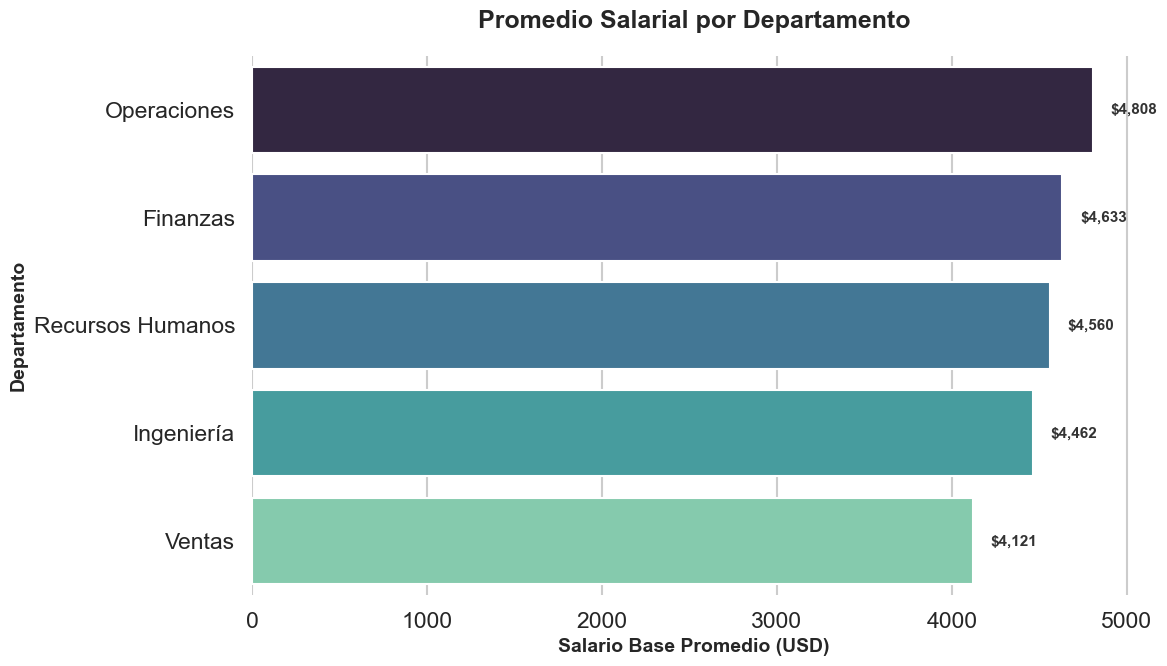

In [1]:
%pip install pymysql
# ==============================================================================
# Descripción: Módulo de extracción, análisis y visualización (BI) conectado a MySQL.
# Arquitectura: Lee directamente de la capa de presentación (Vista SQL)  
#               y optimiza el rendimiento.
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. IMPORTACIÓN DE LIBRERÍAS
# ------------------------------------------------------------------------------
import pandas as pd # La librería principal para análisis y manipulación de datos en Python.
from sqlalchemy import create_engine, exc # SQLAlchemy nos permite crear la conexión a la base de datos de forma segura. 'exc' captura errores de SQL.
import logging # Usado para registrar eventos, advertencias y errores (Trazabilidad). Fundamental en producción.
import matplotlib.pyplot as plt # Librería base para crear gráficos.
import seaborn as sns # Librería de visualización construida sobre matplotlib, ofrece gráficos más atractivos estadísticamente.

# ------------------------------------------------------------------------------
# 2. CONFIGURACIÓN DE TRAZABILIDAD
# ------------------------------------------------------------------------------
# Esto nos permite:
# - Saber la hora exacta en que ocurrió algo.
# - Clasificar mensajes (INFO, WARNING, ERROR, CRITICAL).
# - Enviar estos mensajes a un archivo de registro en un entorno de servidor real.
logging.basicConfig(
    level=logging.INFO, # Mostramos mensajes de nivel INFO en adelante.
    format='%(asctime)s - %(levelname)s - [HR_BI_ENGINE] - %(message)s' # Formato: Fecha - Nivel - [Etiqueta] - Mensaje
)
logger = logging.getLogger(__name__)

# ------------------------------------------------------------------------------
# 3. CLASE PRINCIPAL DEL MOTOR BI
# ------------------------------------------------------------------------------
# Usamos Programación Orientada a Objetos (POO) para mantener el código modular,
# organizado y fácil de mantener o expandir en el futuro.
class HRAnalyticsBI:
    
    # -- Método Constructor --
    # Se ejecuta automáticamente al crear un objeto (instancia) de la clase.
    # Recibe los parámetros de conexión. 
    # NOTA: En producción, NUNCA se ponen credenciales en texto plano;
    # se usan variables de entorno (ej: os.environ.get('DB_PASS')).
    def __init__(self, db_user='root', db_pass='', db_host='localhost', db_port='3306', db_name='hr_analytics'):
        """
        Inicializa el motor de análisis y la conexión a MySQL mediante SQLAlchemy.
        """
        # Se construye la 'Connection String' (Cadena de Conexión) en formato SQLAlchemy para MySQL
        self.db_uri = f"mysql+pymysql://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}"
        
        # Inicializamos variables que usaremos después. 'None' y DataFrames vacíos como buena práctica.
        self.engine = None 
        self.df_analisis = pd.DataFrame() # Aquí guardaremos los datos extraídos
        self.kpi_deptos = pd.DataFrame()  # Aquí guardaremos los cálculos agrupados

    # -- Método para Conectar a la Base de Datos --
    def connect(self):
        """Establece la conexión a la base de datos con manejo de excepciones (try-except)."""
        try:
            # create_engine() prepara la conexión, pero no conecta inmediatamente
            self.engine = create_engine(self.db_uri)
            
            # Usamos el bloque 'with' para abrir la conexión, probarla y asegurarnos de que se cierre al terminar.
            with self.engine.connect():
                logger.info(f"Conexión exitosa a MySQL (Base de datos: {self.engine.url.database})")
                
        # Capturamos cualquier error específico de SQLAlchemy (ej. base de datos apagada, contraseña incorrecta)
        except exc.SQLAlchemyError as e:
            logger.critical(f"Error crítico al conectar a la base de datos: {e}")
            raise # Detenemos la ejecución del programa, no podemos continuar sin base de datos.

    # -- Método para Extraer los Datos --
    def fetch_data(self):
        """
        Extrae los datos desde la Vista SQL (`vw_analisis_salarial`).
        """
        logger.info("Extrayendo datos de la capa de presentación (vw_analisis_salarial)...")
        
        # OJO: Solo hacemos un 'SELECT *' porque la VISTA ya hizo todo el trabajo pesado 
        # (JOINs, Window Functions, filtros). Esto es una excelente práctica de rendimiento.
        query = "SELECT * FROM vw_analisis_salarial;"
        
        try:
            # pandas.read_sql() ejecuta la consulta usando el 'engine' y devuelve un DataFrame
            self.df_analisis = pd.read_sql(query, self.engine)
            logger.info(f"Datos extraídos correctamente. Total de registros analíticos: {len(self.df_analisis)}")
        except Exception as e:
            logger.error(f"Error al ejecutar la consulta analítica: {e}")
            raise

    # -- Método para Calcular los Indicadores Clave (KPIs) --
    def calculate_kpis(self):
        """Calcula las métricas de negocio solicitadas."""
        
        # Verificamos que el DataFrame no esté vacío antes de operar
        if self.df_analisis.empty:
            logger.warning("No hay datos para analizar en la vista. Deteniendo cálculos.")
            return

        logger.info("Calculando KPIs empresariales con Pandas...")

        # -- KPI 1: Promedio y Máximo Global --
        # Utilizamos funciones nativas de pandas (.mean() y .max()) sobre la columna 'salario_base'
        salario_promedio = self.df_analisis['salario_base'].mean()
        salario_maximo = self.df_analisis['salario_base'].max()
        
        # Para dar contexto, buscamos el nombre de la persona que tiene el salario máximo.
        # idxmax() nos da el 'índice' (la fila) donde está el valor máximo, y luego extraemos la columna 'nombre_completo'
        emp_max_salario = self.df_analisis.loc[self.df_analisis['salario_base'].idxmax(), 'nombre_completo']

        # -- KPI 2: Agrupación por Departamento --
        # Usamos .groupby() para agrupar por el nombre del departamento
        # y .agg() para aplicar múltiples cálculos matemáticos a distintas columnas al mismo tiempo.
        self.kpi_deptos = self.df_analisis.groupby('nombre_departamento').agg(
            total_empleados=('empleado_id', 'count'),    # Cuenta cuántos empleados hay
            salario_promedio=('salario_base', 'mean'),   # Promedio del salario base
            salario_maximo=('salario_base', 'max'),      # Máximo salario base
            gasto_total_nomina=('salario_neto', 'sum')   # Suma total de los salarios netos a pagar
        ).reset_index() # .reset_index() convierte 'nombre_departamento' de vuelta a una columna normal

        # Ordenamos los resultados de mayor a menor salario promedio
        self.kpi_deptos = self.kpi_deptos.sort_values(by='salario_promedio', ascending=False)

        # -- 3. Impresión del Reporte Ejecutivo en Consola --
        print("\n" + "="*70)
        print("📊 REPORTE EJECUTIVO - ANALÍTICA DE RECURSOS HUMANOS")
        print("="*70)
        # ':,.2f' formatea el número: coma para miles, punto decimal y 2 decimales.
        print(f"🔹 Salario Promedio Global: ${salario_promedio:,.2f}")
        print(f"🔹 Salario Máximo Global:   ${salario_maximo:,.2f} (Empleado: {emp_max_salario})")
        print("-" * 70)
        print("🔹 MÉTRICAS DETALLADAS POR DEPARTAMENTO:")
        
        # Creamos una función rápida (lambda) para formatear los números de las columnas como moneda
        formato_moneda = lambda x: f"${x:,.2f}"
        
        # Convertimos el DataFrame agrupado a texto (String) aplicando el formato de moneda a las columnas pertinentes
        reporte_str = self.kpi_deptos.to_string(
            index=False, # Ocultamos los números de fila (0, 1, 2...)
            formatters={
                'salario_promedio': formato_moneda,
                'salario_maximo': formato_moneda,
                'gasto_total_nomina': formato_moneda
            }
        )
        print(reporte_str) # Imprimimos la tabla formateada
        print("="*70 + "\n")

    # -- Método para Crear Gráficos (Visualización) --
    def visualize_data(self):
        """Genera un dashboard visual con calidad para presentación a directivos."""
        if self.kpi_deptos.empty:
            return

        logger.info("Renderizando visualizaciones con Seaborn...")
        
        # Definimos el estilo base del gráfico (cuadrícula blanca, texto grande 'talk')
        sns.set_theme(style="whitegrid", context="talk")
        
        # Creamos la figura y los ejes definiendo su tamaño (12 de ancho x 7 de alto)
        fig, ax = plt.subplots(figsize=(12, 7))
        
        # Usamos Seaborn para crear un gráfico de barras horizontales (sns.barplot)
        barplot = sns.barplot(
            x='salario_promedio',       # Eje X: El valor numérico
            y='nombre_departamento',    # Eje Y: Las categorías
            data=self.kpi_deptos,       # Origen de datos: Nuestro DataFrame agrupado
            hue='nombre_departamento',  # Colorea cada barra distinto según el departamento
            palette='mako',             # Paleta de colores profesional predefinida
            legend=False,               # Ocultamos la leyenda porque los nombres ya están en el eje Y
            ax=ax                       # Le indicamos que dibuje en los ejes creados arriba
        )
        
        # Bucle para añadir los números (etiquetas) al lado de cada barra
        for p in barplot.patches:
            width = p.get_width() # Obtenemos el valor de la barra (el salario promedio)
            
            # plt.text() dibuja texto en coordenadas específicas del gráfico
            plt.text(width + 100, # Posición X: al final de la barra + un pequeño margen (100)
                     p.get_y() + p.get_height() / 2, # Posición Y: A la mitad de la altura de la barra
                     f'${width:,.0f}', # El texto a mostrar (formateado sin decimales)
                     ha='left', va='center', # Alineación horizontal (izquierda) y vertical (centro)
                     fontsize=11, fontweight='bold', color='#333333')

        # -- Formateo y limpieza visual del gráfico --
        ax.set_title('Promedio Salarial por Departamento', fontsize=18, fontweight='bold', pad=20)
        ax.set_xlabel('Salario Base Promedio (USD)', fontsize=14, fontweight='bold')
        ax.set_ylabel('Departamento', fontsize=14, fontweight='bold')
        
        # sns.despine() quita las líneas del recuadro superior y derecho del gráfico para un diseño más moderno y limpio.
        sns.despine(left=True, bottom=True)
        
        # Ajusta automáticamente los márgenes para que no se corte ningún texto
        plt.tight_layout()
        
        # Muestra la ventana con el gráfico terminado
        plt.show()

# ------------------------------------------------------------------------------
# 4. PUNTO DE ENTRADA (MAIN)
# ------------------------------------------------------------------------------
# Esta condición asegura que el código solo se ejecute si corremos el archivo directamente 
# (ej. 'python hr_bi_analytics.py') y NO si lo importamos desde otro archivo.
if __name__ == "__main__":
    
    # Creamos un objeto de nuestra clase configurando la conexión a Laragon/MySQL
    bi_engine = HRAnalyticsBI(
        db_user='root', 
        db_pass='',        # En Laragon suele venir sin contraseña por defecto
        db_host='localhost', 
        db_port='3306', 
        db_name='hr_analytics'
    )
    
    # Ejecutamos los métodos en orden lógico envueltos en un try-except para atrapar 
    # errores no previstos durante todo el proceso.
    try:
        bi_engine.connect()          # 1. Conectamos
        bi_engine.fetch_data()       # 2. Extraemos datos
        bi_engine.calculate_kpis()   # 3. Hacemos cálculos e imprimimos el reporte
        bi_engine.visualize_data()   # 4. Dibujamos el gráfico
        
    except Exception as e:
        # Si algo falla en los 4 pasos anteriores, el script no "explota", sino que registra este error
        # e incluye el detalle de la variable 'e' que causó el problema.
        logger.critical(f"El proceso de Business Intelligence ha fallado. Revisa los logs. Detalle: {e}")

## Conclusión

# Modelo Dimensional (Nicole)

# Ejercicio Propuesto

Construir un modelo dimensional para Recursos Humanos.

## Requerimientos

1. Crear:
   - dimensión empleados,
   - dimensión departamentos,
   - dimensión tiempo,
   - fact salarios.

2. Generar:
   - mínimo 100 registros.

3. Analizar:
   - salario promedio,
   - salario máximo,
   - salarios por departamento,
   - salarios por mes.

4. Mostrar:
   - Top 5 empleados con mayor salario.

## Base de datos

```sql
CREATE DATABASE IF NOT EXISTS hr_nicole_analytics;
USE hr_nicole_analytics;

-- Limpieza preventiva por si necesitas volver a correr el código desde cero
DROP VIEW IF EXISTS vw_analisis_salarial_nicole;
DROP TABLE IF EXISTS fact_salarios;
DROP TABLE IF EXISTS dim_tiempo;
DROP TABLE IF EXISTS dim_empleados;
DROP TABLE IF EXISTS dim_departamentos;


-- 2. CREACIÓN DE DIMENSIÓN: DEPARTAMENTOS
CREATE TABLE dim_departamentos (
    departamento_id INT AUTO_INCREMENT PRIMARY KEY,
    nombre_departamento VARCHAR(100) NOT NULL UNIQUE,
    centro_costo VARCHAR(20) NOT NULL
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;

INSERT INTO dim_departamentos (nombre_departamento, centro_costo) VALUES
('Recursos Humanos', 'CC-001'),
('Tecnología', 'CC-002'),
('Ventas', 'CC-003'),
('Finanzas', 'CC-004'),
('Marketing', 'CC-005');


-- 3. CREACIÓN DE DIMENSIÓN: TIEMPO 
CREATE TABLE dim_tiempo (
    tiempo_id INT PRIMARY KEY,
    mes_nombre VARCHAR(20) NOT NULL,
    trimestre VARCHAR(5) NOT NULL
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;

INSERT INTO dim_tiempo (tiempo_id, mes_nombre, trimestre) VALUES
(1, 'Enero', 'Q1'), (2, 'Febrero', 'Q1'), (3, 'Marzo', 'Q1'),
(4, 'Abril', 'Q2'), (5, 'Mayo', 'Q2'), (6, 'Junio', 'Q2'),
(7, 'Julio', 'Q3'), (8, 'Agosto', 'Q3'), (9, 'Septiembre', 'Q3'),
(10, 'Octubre', 'Q4'), (11, 'Noviembre', 'Q4'), (12, 'Diciembre', 'Q4');


-- 4. CREACIÓN DE DIMENSIÓN: EMPLEADOS
CREATE TABLE dim_empleados (
    empleado_id INT AUTO_INCREMENT PRIMARY KEY,
    nombre_completo VARCHAR(150) NOT NULL,
    nivel_seniority VARCHAR(50) NOT NULL
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;


-- 5. CREACIÓN DE LA TABLA DE HECHOS: SALARIOS
CREATE TABLE fact_salarios (
    fact_id INT AUTO_INCREMENT PRIMARY KEY,
    empleado_id INT NOT NULL,
    departamento_id INT NOT NULL,
    tiempo_id INT NOT NULL,
    salario_base DECIMAL(10,2) NOT NULL,
    bono DECIMAL(10,2) NOT NULL,
    salario_neto DECIMAL(10,2) GENERATED ALWAYS AS (salario_base + bono) STORED,
    FOREIGN KEY (empleado_id) REFERENCES dim_empleados(empleado_id),
    FOREIGN KEY (departamento_id) REFERENCES dim_departamentos(departamento_id),
    FOREIGN KEY (tiempo_id) REFERENCES dim_tiempo(tiempo_id)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;


-- 6. PROCEDIMIENTO ALMACENADO PARA GENERAR LOS 105 REGISTROS AUTOMÁTICOS
DELIMITER $$
CREATE PROCEDURE GenerarDatosNicole()
BEGIN
    DECLARE i INT DEFAULT 1;
    DECLARE random_depto INT;
    DECLARE random_mes INT;
    DECLARE random_base DECIMAL(10,2);
    DECLARE random_bono DECIMAL(10,2);
    DECLARE seniority VARCHAR(50);
    
    WHILE i <= 105 DO
        -- Asignamos niveles de experiencia aleatorios
        SET seniority = ELT(FLOOR(1 + RAND() * 4), 'Junior', 'Analista', 'Especialista', 'Gerente');
        
        -- Insertamos empleados con un identificador numérico correlativo uniforme
        INSERT INTO dim_empleados (nombre_completo, nivel_seniority) 
        VALUES (CONCAT('Empleado Nicole ', i), seniority);
        
        -- Generamos valores numéricos aleatorios pero con coherencia empresarial
        SET random_depto = FLOOR(1 + RAND() * 5);
        SET random_mes = FLOOR(1 + RAND() * 12);
        SET random_base = ROUND(900 + (RAND() * 3100), 2);
        SET random_bono = ROUND(50 + (RAND() * 450), 2);
        
        -- Insertamos directamente en la tabla central de hechos
        INSERT INTO fact_salarios (empleado_id, departamento_id, tiempo_id, salario_base, bono)
        VALUES (i, random_depto, random_mes, random_base, random_bono);
        
        SET i = i + 1;
    END WHILE;
END$$
DELIMITER ;

-- Ejecutamos de inmediato el procedimiento creado arriba
CALL GenerarDatosNicole();


-- 7. CAPA DE PRESENTACIÓN: VISTA ANALÍTICA CONSOLIDADA 
CREATE VIEW vw_analisis_salarial_nicole AS
SELECT 
    f.fact_id,
    e.nombre_completo,
    e.nivel_seniority,
    d.nombre_departamento,
    d.centro_costo,
    t.tiempo_id,
    t.mes_nombre,
    t.trimestre,
    f.salario_base,
    f.bono,
    f.salario_neto
FROM fact_salarios f
JOIN dim_empleados e ON f.empleado_id = e.empleado_id
JOIN dim_departamentos d ON f.departamento_id = d.departamento_id
JOIN dim_tiempo t ON f.tiempo_id = t.tiempo_id;

## Registros


```sql
dim_empleados = pd.read_sql("SELECT * FROM dim_empleados", engine)
dim_departamentos = pd.read_sql("SELECT * FROM dim_departamentos", engine)
dim_tiempo = pd.read_sql("SELECT * FROM dim_tiempo", engine)
fact_salarios = pd.read_sql("SELECT * FROM fact_salarios", engine)

# cargamos la vista consolidada que une todo tu modelo en estrella


modelo_completo = pd.read_sql("SELECT * FROM vw_analisis_salarial_nicole", engine)

print("==================================================")
print("     REGISTROS CARGADOS DESDE LA BASE DE DATOS    ")
print("==================================================")
print(f"✔ Dimensión Empleados:    {len(dim_empleados)} registros.")
print(f"✔ Dimensión Departamentos: {len(dim_departamentos)} registros.")
print(f"✔ Dimensión Tiempo:       {len(dim_tiempo)} registros.")
print(f"✔ Tabla de Hechos:        {len(fact_salarios)} registros.")
print("-" * 50)
print("Vista previa de los datos consolidados:")
print(modelo_completo[["nombre_completo", "nombre_departamento", "mes_nombre", "salario_neto"]].head())

## Resultados

```sql

# 1. REQUERIMIENTO: Analizar salario promedio y máximo general
promedio_general = modelo_completo["salario_neto"].mean()
maximo_general = modelo_completo["salario_neto"].max()

print(f"SALARIO PROMEDIO GENERAL: ${promedio_general:,.2f}")
print(f"SALARIO MÁXIMO GENERAL:  ${maximo_general:,.2f}")
print("-" * 60)

# 2. REQUERIMIENTO: Analizar salarios promedio y máximo por departamento
print("ANÁLISIS DE SALARIOS POR DEPARTAMENTO:")
por_depto = modelo_completo.groupby("nombre_departamento").agg(
    salario_promedio=("salario_neto", "mean"),
    salario_maximo=("salario_neto", "max"),
    empleados_en_area=("fact_id", "count")
).reset_index()
print(por_depto.to_string(index=False))
print("-" * 60)

# 3. REQUERIMIENTO: Analizar salarios promedio por mes
print("ANÁLISIS DE SALARIOS POR MES:")
por_mes = modelo_completo.groupby(["tiempo_id", "mes_nombre"]).agg(
    salario_promedio=("salario_neto", "mean"),
    monto_total_pago=("salario_neto", "sum")
).reset_index().sort_values(by="tiempo_id")
print(por_mes[["mes_nombre", "salario_promedio", "monto_total_pago"]].to_string(index=False))
print("-" * 60)

# 4. REQUERIMIENTO: Mostrar Top 5 empleados con mayor salario
print("TOP 5 EMPLEADOS CON MAYOR SALARIO:")
top_5 = modelo_completo.sort_values(by="salario_neto", ascending=False).head(5)
print(top_5[["nombre_completo", "nombre_departamento", "nivel_seniority", "salario_neto"]].to_string(index=False))

## Visualización en python

```sql

# Creamos una ventana ancha  para poner dos gráficos en paralelo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# --- GRÁFICO 1: Salario Promedio por Departamento  ---
sns.barplot(
    data=por_depto, 
    x="nombre_departamento", 
    y="salario_promedio", 
    palette="Blues_r", 
    ax=axes[0]
)
axes[0].set_title("Salario Promedio por Departamento (Nicole)", fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel("Departamento Organizacional", fontsize=11)
axes[0].set_ylabel("Salario Promedio ($)", fontsize=11)
axes[0].tick_params(axis='x', rotation=15) # Rotamos un poco los nombres para que no se amontonen

# --- GRÁFICO 2: Evolución del Salario Promedio por Mes  ---
sns.lineplot(
    data=por_mes, 
    x="mes_nombre", 
    y="salario_promedio", 
    marker="o", 
    color="teal", 
    linewidth=2.5, 
    ax=axes[1]
)
axes[1].set_title("Evolución del Salario Promedio Mensual", fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel("Meses del Año (Eje Temporal)", fontsize=11)
axes[1].set_ylabel("Salario Promedio ($)", fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

# Ajustamos los espacios entre gráficos para que se vea impecable
plt.tight_layout()

# Desplegamos los gráficos directamente en el notebook
plt.show()

## Conclusión

# Diseño de tablas fact y dimención (Eunice)

## Ejercicio Propuesto

Construir un modelo dimensional para Recursos Humanos.

### Requerimientos

1. Crear:
   - dimensión empleados,
   - dimensión departamentos,
   - dimensión tiempo,
   - fact salarios.

2. Utilizar:
   - surrogate keys.

3. Generar:
   - mínimo 300 registros.

4. Analizar:
   - salario promedio,
   - salario máximo,
   - salarios por departamento,
   - salarios por mes.

5. Mostrar:
   - Top 10 empleados con mayor salario.

## Base de datos

```sql
-- CREAR BASE DE DATOS

CREATE DATABASE recursos_humanos_dw;
USE recursos_humanos_dw;

-- DIMENSIÓN EMPLEADOS

CREATE TABLE dim_empleados (
    empleado_key INT AUTO_INCREMENT PRIMARY KEY,
    nombre_empleado VARCHAR(100),
    genero VARCHAR(1),
    puesto VARCHAR(50),
    nivel_academico VARCHAR(50)

);

-- DIMENSIÓN DEPARTAMENTOS

CREATE TABLE dim_departamentos (
    departamento_key INT AUTO_INCREMENT PRIMARY KEY,
    nombre_departamento VARCHAR(100),
    ubicacion VARCHAR(100)

);

-- DIMENSIÓN TIEMPO

CREATE TABLE dim_tiempo (
    fecha_key INT AUTO_INCREMENT PRIMARY KEY,
    dia INT,
    mes VARCHAR(20),
    anio INT
);

-- FACT SALARIOS

CREATE TABLE fact_salarios (
    salario_id INT AUTO_INCREMENT PRIMARY KEY,
    empleado_key INT,
    departamento_key INT,
    fecha_key INT,
    salario_base DECIMAL(10,2),
    bono DECIMAL(10,2),
    descuento DECIMAL(10,2),
    salario_total DECIMAL(10,2),
    CONSTRAINT fk_empleado
        FOREIGN KEY (empleado_key)
        REFERENCES dim_empleados(empleado_key),
    CONSTRAINT fk_departamento
        FOREIGN KEY (departamento_key)
        REFERENCES dim_departamentos(departamento_key),
    CONSTRAINT fk_fecha
        FOREIGN KEY (fecha_key)
        REFERENCES dim_tiempo(fecha_key)
);
```

---

## Registros

```sql
INSERT INTO dim_departamentos (
    nombre_departamento,
    ubicacion
)
VALUES
('Finanzas', 'Edificio A'),
('Tecnología', 'Edificio B'),
('Recursos Humanos', 'Edificio C'),
('Ventas', 'Edificio D'),
('Operaciones', 'Edificio E');

INSERT INTO dim_empleados (
    nombre_empleado,
    genero,
    puesto,
    nivel_academico
)
VALUES
('Ana López', 'F', 'Analista', 'Universitario'),
('Carlos Pérez', 'M', 'Gerente', 'Maestría'),
('Sofía Ramírez', 'F', 'Asistente', 'Técnico'),
('Luis Martínez', 'M', 'Supervisor', 'Universitario'),
('María Hernández', 'F', 'Coordinador', 'Maestría'),
('José Rivera', 'M', 'Analista', 'Universitario'),
('Elena Flores', 'F', 'Asistente', 'Técnico'),
('Ricardo Gómez', 'M', 'Supervisor', 'Universitario'),
('Patricia Castro', 'F', 'Gerente', 'Maestría'),
('Fernando Ruiz', 'M', 'Coordinador', 'Universitario');

INSERT INTO dim_tiempo (
    dia,
    mes,
    anio
)
VALUES
(1, 'Enero', 2026),
(2, 'Enero', 2026),
(3, 'Enero', 2026),
(4, 'Enero', 2026),
(5, 'Enero', 2026),
(6, 'Febrero', 2026),
(7, 'Febrero', 2026),
(8, 'Febrero', 2026),
(9, 'Febrero', 2026),
(10, 'Febrero', 2026),
(11, 'Marzo', 2026),
(12, 'Marzo', 2026),
(13, 'Marzo', 2026),
(14, 'Marzo', 2026),
(15, 'Marzo', 2026);

DELIMITER $$
CREATE PROCEDURE insertar_salarios()
BEGIN
    DECLARE i INT DEFAULT 1;
    WHILE i <= 300 DO
        INSERT INTO fact_salarios (
            empleado_key,
            departamento_key,
            fecha_key,
            salario_base,
            bono,
            descuento,
            salario_total
        )
        VALUES (
            FLOOR(1 + RAND() * 10),
            FLOOR(1 + RAND() * 5),
            FLOOR(1 + RAND() * 15),
            ROUND(500 + RAND() * 2500, 2),
            ROUND(50 + RAND() * 500, 2),
            ROUND(10 + RAND() * 300, 2),
            ROUND(
                (
                    (500 + RAND() * 2500)
                    +
                    (50 + RAND() * 500)
                    -
                    (10 + RAND() * 300)
                ),
            2)
        );
        SET i = i + 1;
    END WHILE;
END $$
DELIMITER ;

CALL insertar_salarios();
```

---

## Resultados
La consulta final permitió unir la tabla `fact_salarios` con las tablas dimensión para construir el modelo analítico de Recursos Humanos. La tabla principal es `fact_salarios`, ya que contiene los datos numéricos relacionados con los salarios de los empleados.

Las tablas dimensión agregan información descriptiva para entender mejor los datos:

- `dim_empleados` contiene información de los empleados.
- `dim_departamentos` contiene información de los departamentos.
- `dim_tiempo` contiene información de fechas y meses.

Las relaciones entre tablas se realizaron utilizando surrogate keys, que son identificadores numéricos creados automáticamente con `AUTO_INCREMENT`. Estas claves ayudan a mejorar el rendimiento y facilitan las relaciones entre tablas.

Las surrogate keys utilizadas fueron:

- `empleado_key`
- `departamento_key`
- `fecha_key`

La estructura del modelo quedó organizada de la siguiente manera:

DIM_EMPLEADOS --------|
                       |
DIM_DEPARTAMENTOS ----|---- FACT_SALARIOS
                       |
DIM_TIEMPO -----------|

Gracias a esta estructura fue posible analizar salarios por empleado, departamento y mes, además de calcular indicadores como salario promedio y salario máximo.

La siguiente tabla muestra el resultado final del modelo analítico:

| salario_id | nombre_empleado | nombre_departamento | mes | salario_base | bono | descuento | salario_total |
|---|---|---|---|---|---|---|---|
| 7 | Ana López | Finanzas | Enero | 2618.84 | 374.20 | 219.80 | 2271.97 |
| 12 | María Hernández | Finanzas | Enero | 638.46 | 231.23 | 203.84 | 2418.91 |
| 18 | María Hernández | Finanzas | Enero | 685.93 | 282.89 | 41.75 | 1365.98 |
| 20 | Ricardo Gómez | Finanzas | Febrero | 2343.59 | 424.23 | 168.99 | 1538.99 |
| 23 | Elena Flores | Finanzas | Enero | 1128.86 | 266.37 | 132.73 | 2094.98 |
| 24 | Fernando Ruiz | Finanzas | Enero | 2370.86 | 174.00 | 308.50 | 1033.26 |
| 36 | Luis Martínez | Finanzas | Febrero | 1284.24 | 63.90 | 69.36 | 3044.55 |
| 37 | Ana López | Finanzas | Marzo | 774.42 | 259.89 | 240.89 | 2299.60 |
| 48 | Ricardo Gómez | Finanzas | Marzo | 2672.06 | 205.14 | 293.48 | 1185.76 |

---


## Instalando librerias

In [ ]:
!pip install pandas
!pip install matplotlib
!pip install mysql-connector-python

## Visualización en python
Para la visualización del modelo dimensional se utilizó Python junto con las librerías `pandas`, `matplotlib` y `mysql.connector`. La librería `mysql.connector` permitió establecer conexión con la base de datos MySQL/MariaDB y leer las tablas del Data Warehouse. Posteriormente, `pandas` fue utilizada para construir el modelo analítico mediante la unión de la tabla fact con las tablas dimensión, además de realizar cálculos de KPIs como salario promedio, salario máximo, salarios por departamento y salarios por mes. Finalmente, `matplotlib` se utilizó para generar gráficas de barras que permiten visualizar de forma clara el comportamiento de los salarios por departamento, facilitando el análisis y la interpretación de la información.

C:\Users\MINEDUCYT\AppData\Local\Temp\ipykernel_15884\209974298.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dim_empleados = pd.read_sql(
C:\Users\MINEDUCYT\AppData\Local\Temp\ipykernel_15884\209974298.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dim_departamentos = pd.read_sql(
C:\Users\MINEDUCYT\AppData\Local\Temp\ipykernel_15884\209974298.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dim_tiempo = pd.read_sql(
C:\Users\MINEDUCYT\AppData\Local\Temp\ipykernel_15884\209974298.py:42: UserWarning: pandas

Salario Promedio: 1838.98
Salario Máximo: 3362.74

Salarios por Departamento:

nombre_departamento
Finanzas             88692.86
Operaciones         129909.51
Recursos Humanos    106114.29
Tecnología          100729.06
Ventas              126248.06
Name: salario_total, dtype: float64

Salarios por Mes:

mes
Enero      165144.15
Febrero    203302.05
Marzo      183247.58
Name: salario_total, dtype: float64

Top 10 Empleados:

nombre_empleado
María Hernández    78396.20
Luis Martínez      67105.07
José Rivera        65404.86
Ana López          61776.95
Carlos Pérez       58117.64
Sofía Ramírez      57918.95
Fernando Ruiz      45961.78
Elena Flores       44737.58
Ricardo Gómez      38192.68
Patricia Castro    34082.07
Name: salario_total, dtype: float64


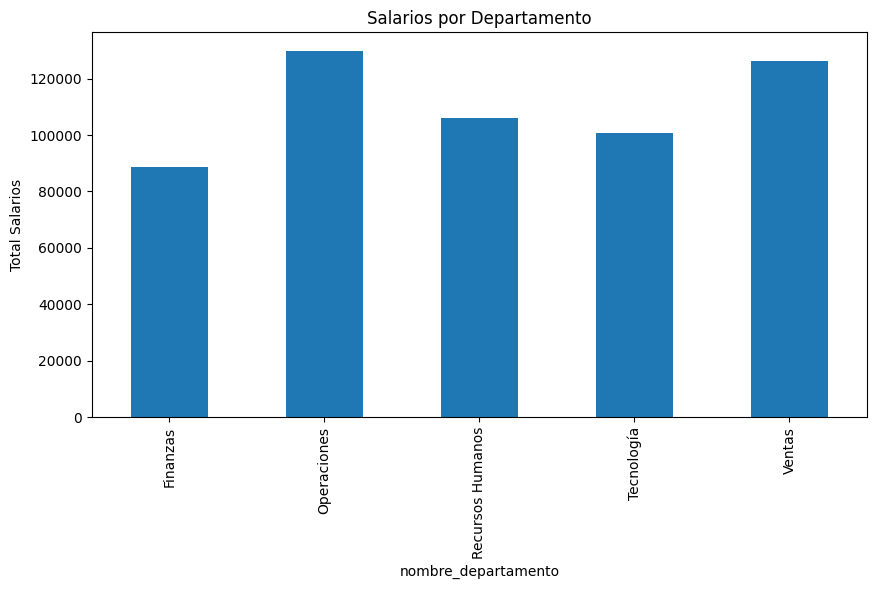

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector


# Importa librerías para análisis, gráficas y conexión a la base de datos


# Crea conexión con MySQL o MariaDB


conexion = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="recursos_humanos_dw"
)


# Lee tablas dimensión desde la base de datos


dim_empleados = pd.read_sql(
    "SELECT * FROM dim_empleados",
    conexion
)

dim_departamentos = pd.read_sql(
    "SELECT * FROM dim_departamentos",
    conexion
)

dim_tiempo = pd.read_sql(
    "SELECT * FROM dim_tiempo",
    conexion
)


# Lee tabla fact desde la base de datos


fact_salarios = pd.read_sql(
    "SELECT * FROM fact_salarios",
    conexion
)


# Construye modelo analítico uniendo fact y dimensiones


modelo = fact_salarios.merge(
    dim_empleados,
    on="empleado_key"
).merge(
    dim_departamentos,
    on="departamento_key"
).merge(
    dim_tiempo,
    on="fecha_key"
)


# Calcula salario promedio


salario_promedio = round(
    modelo["salario_total"].mean(),
    2
)

print(
    "Salario Promedio:",
    salario_promedio
)


# Calcula salario máximo


salario_maximo = modelo[
    "salario_total"
].max()

print(
    "Salario Máximo:",
    salario_maximo
)


# Calcula salarios agrupados por departamento


salarios_departamento = modelo.groupby(
    "nombre_departamento"
)["salario_total"].sum()

print("\nSalarios por Departamento:\n")

print(salarios_departamento)


# Calcula salarios agrupados por mes


salarios_mes = modelo.groupby(
    "mes"
)["salario_total"].sum()

print("\nSalarios por Mes:\n")

print(salarios_mes)


# Obtiene top 10 empleados con mayor salario


top_empleados = modelo.groupby(
    "nombre_empleado"
)["salario_total"].sum().sort_values(
    ascending=False
).head(10)

print("\nTop 10 Empleados:\n")

print(top_empleados)


# Grafica salarios por departamento


salarios_departamento.plot(
    kind="bar",
    figsize=(10,5),
    title="Salarios por Departamento"
)

plt.ylabel("Total Salarios")

plt.show()


# Cierra conexión con la base de datos


conexion.close()

## Conclusión

El uso de tablas fact y dimensión permitió organizar la información de Recursos Humanos de una manera más clara y eficiente para realizar análisis. La tabla `fact_salarios` almacenó los datos numéricos relacionados con salarios, bonos y descuentos, mientras que las tablas dimensión agregaron información descriptiva sobre empleados, departamentos y tiempo.

Gracias a esta estructura fue posible realizar consultas y generar indicadores como salario promedio, salario máximo, salarios por departamento y salarios por mes de forma más sencilla y ordenada. Además, el modelo dimensional facilita la creación de reportes, dashboards y análisis históricos.

Las surrogate keys fueron importantes porque ayudaron a relacionar las tablas utilizando identificadores numéricos simples creados automáticamente con `AUTO_INCREMENT`. Esto mejora el rendimiento de las consultas, facilita las relaciones entre tablas y evita depender de datos reales o complejos como nombres o códigos largos. En este caso, claves como `empleado_key`, `departamento_key` y `fecha_key` permitieron conectar correctamente todas las dimensiones con la tabla fact.